# MFCC CNN: Compacted architecture for hls4ml + QAT

## Changes related to original architecture 

For using `Strategy='Latency'` with `ReuseFactor=1` (min latency in FPGA),
each layer must have ≤ 4096 parameters. The original model **exceeded this limit**:

| Layer (original) | Elements | Status |
|---|---|---|
| `Conv2D(32)` | 3×3×2×32 = 576 | ✓ |
| `Conv2D(64)` | 3×3×32×64 = **18,432** | ✗ |
| `Dense(128)` | 22,400×128 = **2,867,200** | ✗ |

The new compact architecture (3 Conv blocks + small Dense) respects the limit in all layers.



In [1]:
import os, json, re, warnings

if 'CUDA_VISIBLE_DEVICES' not in os.environ:
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # CPU only

_vitis_hls = os.environ.get('XILINX_HLS', '')

if _vitis_hls and _vitis_hls not in os.environ.get('PATH', ''):
    os.environ['PATH'] = _vitis_hls + '/bin:' + os.environ['PATH']
elif not _vitis_hls:
    import glob as _glob
    _candidates = sorted(_glob.glob('/tools/Xilinx/Vitis_HLS/*/bin/vitis_hls'))
    if _candidates:
        _detected = os.path.dirname(os.path.dirname(_candidates[-1]))
        os.environ['XILINX_HLS']  = _detected
        os.environ['XILINX_VITIS'] = _detected.replace('Vitis_HLS', 'Vitis')
        os.environ['PATH'] = _detected + '/bin:' + os.environ['PATH']
        print(f'Vitis HLS detected: {_detected}')
    else:
        print('WARNING: Vitis HLS not found. Synthesis will not be available.')

import tensorflow as tf
import pickle
import numpy as np
import matplotlib.pyplot as plt


from qkeras import QConv2D, QDense, QActivation, quantized_bits, quantized_relu
from qkeras.utils import _add_supported_quantized_objects

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    InputLayer, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, Activation, Conv2D
)
from tensorflow.keras.optimizers import Adam
import hls4ml

RANDOM_SEED = 55
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# Hardware target
FPGA_PART    = 'xck26-sfvc784-2LV-c'
CLOCK_PERIOD = 5          # ns → 200 MHz
TARGET_SNR   = '76dB'
HLS_BASE_DIR = './hls4ml_output_compact'

# Training hyperparameters
MAX_EPOCHS    = 150
LEARNING_RATE = 1e-3      # LR for base float model
PATIENCE      = 20

QKERAS_CO = {}
_add_supported_quantized_objects(QKERAS_CO)

# Show active device
gpus = tf.config.list_physical_devices('GPU')
print('Training device:', 'GPU' if gpus else 'CPU')
print('TF:', tf.__version__)
print('hls4ml:', hls4ml.__version__)


Vitis HLS detected: /tools/Xilinx/Vitis_HLS/2023.2


2026-03-31 17:42:43.845735: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-31 17:42:43.845788: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-31 17:42:43.845799: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 17:42:43.919903: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training device: CPU
TF: 2.14.0
hls4ml: 1.2.0


2026-03-31 17:42:51.951907: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-03-31 17:42:51.951969: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: chejimenez-Z170XP-SLI
2026-03-31 17:42:51.951981: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: chejimenez-Z170XP-SLI
2026-03-31 17:42:51.952133: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: 535.288.1
2026-03-31 17:42:51.952167: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: 535.288.1
2026-03-31 17:42:51.952175: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:309] kernel version seems to match DSO: 535.288.1


## Load dataset parameters

In [2]:
DATASETS_PATH = 'MFCC_datasets'
METADATA_PATH = os.path.join(DATASETS_PATH, 'metadata.json')

if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH, 'r') as f:
        metadata = json.load(f)
    MFCC_input_shape = tuple(metadata['MFCC_input_shape'])
    NUM_CLASSES      = metadata['num_classes']
    N_MFCC           = metadata.get('N_MFCC', 20)
    MFCC_FRAMES      = metadata.get('MFCC_FRAMES')
    HOP_LENGTH       = metadata.get('HOP_LENGTH', 2250)
    N_FFT            = metadata.get('N_FFT', 2048)
    SAMPLING_FREQ    = metadata.get('SAMPLING_FREQ', 48000)
    batch_size       = metadata.get('batch_size', 32)
    subfolders       = metadata.get('subfolders', [])
    unique_labels    = metadata.get('labels', [])
    print('Metadata loaded from metadata.json')
else:
    raise FileNotFoundError(
        'metadata.json not found in MFCC_datasets/ -- '
        'run MFCC_dataset_generation.ipynb first.'
    )

# Verify dataset BRAM-Opt v2 (hop=2250, frames=64)
assert MFCC_FRAMES == 64 and HOP_LENGTH == 2250, (
    f'\n[ERROR] Dataset incompatible with BRAM-Opt v2 architecture:\n'
    f'  MFCC_FRAMES = {MFCC_FRAMES}  (expected: 64)\n'
    f'  HOP_LENGTH  = {HOP_LENGTH}  (expected: 2250)\n'
    'Solution: run MFCC_dataset_generation.ipynb with hop_length=2250.'
)

print(f'  MFCC input shape : {MFCC_input_shape}')
print(f'  Num classes      : {NUM_CLASSES}')
print(f'  N_MFCC           : {N_MFCC}')
print(f'  MFCC_FRAMES      : {MFCC_FRAMES}  '
      f'(hop={HOP_LENGTH} => {HOP_LENGTH/SAMPLING_FREQ*1000:.1f} ms/frame)')
print(f'  Sampling freq    : {SAMPLING_FREQ} Hz')
print(f'  Classes          : {subfolders}')
print('\n[OK] Dataset BRAM-Opt v2 verified (MFCC_FRAMES=64, hop_length=2250)')

# Load datasets
SPEC_PATH = os.path.join(DATASETS_PATH, 'element_spec.pkl')
with open(SPEC_PATH, 'rb') as f:
    specs = pickle.load(f)

MFCC_dataset_train_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, 'train_batches'),
    element_spec=specs['train']
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_validation_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, 'validation_batches'),
    element_spec=specs['validation']
).prefetch(tf.data.AUTOTUNE)

for bX, by in MFCC_dataset_train_batches.take(1):
    print(f'Train batch: X={bX.shape}, y={by.shape}')
print('Datasets cargados.')


Metadata loaded from metadata.json
  MFCC input shape : (20, 64, 2)
  Num classes      : 10
  N_MFCC           : 20
  MFCC_FRAMES      : 64  (hop=2250 => 46.9 ms/frame)
  Sampling freq    : 48000 Hz
  Classes          : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']

[OK] Dataset BRAM-Opt v2 verified (MFCC_FRAMES=64, hop_length=2250)
Train batch: X=(32, 20, 64, 2), y=(32,)
Datasets cargados.


## BRAM-Opt v2 Architecture -- input `(20, 64, 2)`

Input generated by `MFCC_dataset_generation.ipynb`
with `hop_length=2250`, `MFCC_FRAMES=64`.

```
Input  (20, 64, 2)
  +- Conv2D(8, 3x3, same)   3x3x2x8 =  144 params OK  ->  (20, 64, 8)
  +- BN + ReLU
  +- MaxPool(2, 2)                                    ->  (10, 32, 8)
  +- Conv2D(8, 3x3, same)   3x3x8x8 =  576 params OK  ->  (10, 32, 8)
  +- BN + ReLU
  +- MaxPool(2, 4)                                    ->  ( 5,  8, 8)
  +- Conv2D(8, 3x3, same)   3x3x8x8 =  576 params OK  ->  ( 5,  8, 8)
  +- BN + ReLU
  +- MaxPool(5, 4)                                    ->  ( 1,  2, 8)
  +- Flatten                                          ->  16
  +- Dense(16)               16x16  =  256 params OK
  +- Dense(NUM_CLASSES)      16x10  =  160 params OK
```

### DSPs (with ReuseFactor)

| Capa | MACs | RF | DSPs |
|---|---|---|---|
| conv1 | 144 | 1 | 144 |
| conv2 | 576 | 4 | 144 |
| conv3 | 576 | 4 | 144 |
| dense1 | 256 | 1 | 256 |
| output | 160 | 1 | 160 |
| **Total** | | | **848 (68 %)** OK |

### BRAM_18K (io_stream)

| Input | FIFO depth | BRAM_18K est. | % KV260 |
|---|---|---|---|
| Original (20x282) | 5640 | ~681 | 236 % FAIL |
| **BRAM-Opt (20x64)** | **1280** | **~120** | **42 %** OK |


In [3]:
# --- Model definition -- BRAM-Opt v2 -----------------------------------

def build_compact_float_model(input_shape, n_classes):
    """
    CNN BRAM-Opt v2 -- all layers <= 576 parameters.
    Designed for input shape (20, 64, 2).

    Spatial reduction MFCC (20, 64):
      MaxPool(2, 2)  ->  (10, 32)
      MaxPool(2, 4)  ->  ( 5,  8)
      MaxPool(5, 4)  ->  ( 1,  2)  ->  Flatten: 1x2x8 = 16
    """
    model = Sequential([
        InputLayer(input_shape),
        # -- Block 1: (20, 64, 2) -> (10, 32, 8) ---------------------------
        Conv2D(8, (3, 3), padding='same', name='conv1'),   # 144 params
        BatchNormalization(name='bn1'),
        Activation('relu', name='act1'),
        MaxPooling2D((2, 2), name='pool1'),
        # -- Block 2: (10, 32, 8) -> (5, 8, 8) -----------------------------
        Conv2D(8, (3, 3), padding='same', name='conv2'),   # 576 params
        BatchNormalization(name='bn2'),
        Activation('relu', name='act2'),
        MaxPooling2D((2, 4), name='pool2'),
        # -- Block 3: (5, 8, 8) -> (1, 2, 8) -------------------------------
        Conv2D(8, (3, 3), padding='same', name='conv3'),   # 576 params
        BatchNormalization(name='bn3'),
        Activation('relu', name='act3'),
        MaxPooling2D((5, 4), name='pool3'),
        # -- Classifier: 16 -> 16 -> n_classes -----------------------------
        Flatten(name='flatten'),
        Dense(16, name='dense1'),                          # 256 params
        Activation('relu', name='act4'),
        Dropout(0.3, name='dropout'),
        Dense(n_classes, name='output'),                   # 160 params (N=10)
        Activation('softmax', name='softmax'),
    ], name='Compact_CNN_Float_v2')
    return model


def build_compact_qat_model(input_shape, n_classes, bits,
                             int_bits_kernel, int_bits_activation):
    """
    QAT version of the BRAM-Opt v2 model.

    int_bits separated for kernel and activations: in 4-bit the
    activations need more range to avoid clipping of BN+ReLU.
    """
    kq = quantized_bits(bits, int_bits_kernel, keep_negative=1, alpha=1)
    aq = quantized_relu(bits, int_bits_activation)

    model = Sequential([
        InputLayer(input_shape),
        # -- Block 1 --------------------------------------------------------
        QConv2D(8, (3, 3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv1'),
        BatchNormalization(name='bn1'),
        QActivation(activation=aq, name='act1'),
        MaxPooling2D((2, 2), name='pool1'),
        # -- Block 2 --------------------------------------------------------
        QConv2D(8, (3, 3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv2'),
        BatchNormalization(name='bn2'),
        QActivation(activation=aq, name='act2'),
        MaxPooling2D((2, 4), name='pool2'),
        # -- Block 3 --------------------------------------------------------
        QConv2D(8, (3, 3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv3'),
        BatchNormalization(name='bn3'),
        QActivation(activation=aq, name='act3'),
        MaxPooling2D((5, 4), name='pool3'),
        # -- Classifier ----------------------------------------------------
        Flatten(name='flatten'),
        QDense(16, kernel_quantizer=kq, bias_quantizer=kq, name='dense1'),
        QActivation(activation=aq, name='act4'),
        Dropout(0.3, name='dropout'),
        QDense(n_classes, kernel_quantizer=kq, bias_quantizer=kq,
               name='output'),
        Activation('softmax', name='softmax'),
    ], name=f'Compact_CNN_QAT_{bits}bit_v2')
    return model


# --- Utilities -------------------------------------------------------------

def verify_layer_sizes(model, max_elements=4096):
    """Verifies that each layer's weights have <= max_elements elements."""
    print(f'\nVerifying layer sizes (limit: {max_elements})')
    print('-' * 68)
    all_ok = True
    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue
        w = weights[0]
        n = int(np.prod(w.shape))
        ok = n <= max_elements
        status = 'OK' if ok else 'EXCEDE'
        if not ok:
            all_ok = False
        print(f'  {status:10s} {layer.name:20s}: {n:7d} elements | shape {w.shape}')
    print('-' * 68)
    if all_ok:
        print('[OK] All layers <= 4096')
    else:
        print('[WARN] Some layers exceed 4096 -> use Strategy=Resource with high ReuseFactor')
    return all_ok


def transfer_float_weights(float_model, qat_model):
    """Transfers weights from the float model to the QAT model (same architecture)."""
    float_wl = [l for l in float_model.layers if l.get_weights()]
    qat_wl   = [l for l in qat_model.layers  if l.get_weights()]
    n_ok = 0
    for fl, ql in zip(float_wl, qat_wl):
        try:
            ql.set_weights(fl.get_weights())
            n_ok += 1
        except ValueError:
            print(f'  Omitted: {fl.name} -> {ql.name} (incompatible shapes)')
    print(f'  Weights transferred: {n_ok} layers.')


def save_history(history_obj, filepath):
    """Saves Keras training history to JSON (cumulative)."""
    new_hist = {k: [float(v) for v in vals]
                for k, vals in history_obj.history.items()}
    if os.path.exists(filepath):
        with open(filepath) as f:
            old_hist = json.load(f)
        for key, vals in new_hist.items():
            old_hist.setdefault(key, []).extend(vals)
        combined = old_hist
    else:
        combined = new_hist
    with open(filepath, 'w') as f:
        json.dump(combined, f, indent=2)
    print(f'History saved -> {filepath}')


def load_history(filepath):
    with open(filepath) as f:
        return json.load(f)


def plot_training_history(history_dict, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history_dict.get('accuracy',     []), label='Train')
    axes[0].plot(history_dict.get('val_accuracy', []), label='Validation')
    axes[0].set(xlabel='Epoch', ylabel='Accuracy', ylim=[0, 1], title='Accuracy')
    axes[0].legend()
    for key in ['loss', 'val_loss']:
        vals = history_dict.get(key, [])
        if not vals:
            continue
        mx = max(vals) or 1.0
        axes[1].plot([v / mx for v in vals], label=key)
    axes[1].set(xlabel='Epoch', ylabel='Loss (Normalized)',
                title='Loss (Normalized)', ylim=[0, 1])
    axes[1].legend()
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


print('Functions defined!')


Functions defined!


## Train the compact float model

If a saved checkpoint exists it is loaded directly.  
If not, the model is trained from scratch with:
- Adam with `LR=1e-3` + `ReduceLROnPlateau`
- `EarlyStopping(patience=20)`
- `ModelCheckpoint` (saves the best model by `val_accuracy`)

Loading model from: ./ckpt_compact_float/compact_float_best.h5


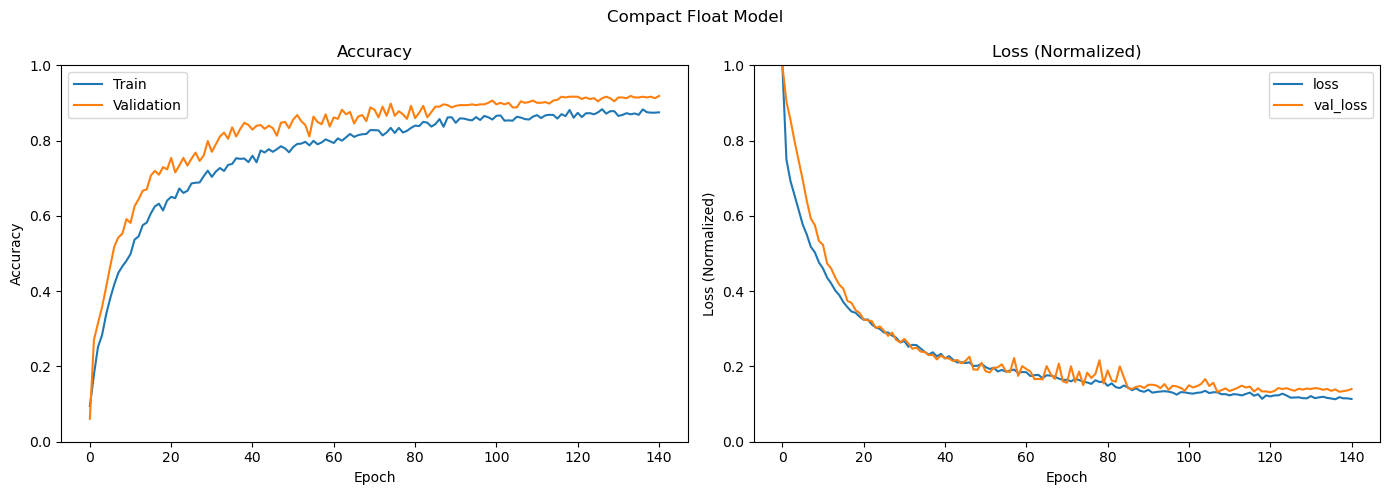


Float model evaluation:
16/16 [==============================] - 0s 7ms/step - loss: 0.3138 - accuracy: 0.9167
  Val Loss: 0.3138 | Val Accuracy: 0.9167


In [4]:
COMPACT_CKPT_DIR  = './ckpt_compact_float'
COMPACT_CKPT_PATH = f'{COMPACT_CKPT_DIR}/compact_float_best.h5'
COMPACT_HIST_PATH = f'{COMPACT_CKPT_DIR}/compact_float_history.json'
os.makedirs(COMPACT_CKPT_DIR, exist_ok=True)

if os.path.exists(COMPACT_CKPT_PATH):
    print(f'Loading model from: {COMPACT_CKPT_PATH}')
    model_compact_float = tf.keras.models.load_model(COMPACT_CKPT_PATH)
    model_compact_float.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
else:
    print('Training model from scratch...')
    model_compact_float = build_compact_float_model(MFCC_input_shape, NUM_CLASSES)
    model_compact_float.summary()

    verify_layer_sizes(model_compact_float)

    model_compact_float.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks_float = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            verbose=1,
            min_lr=1e-6
        )
    ]

    history_float = model_compact_float.fit(
        MFCC_dataset_train_batches,
        epochs=MAX_EPOCHS,
        validation_data=MFCC_dataset_validation_batches,
        callbacks=callbacks_float
    )

    # Save best model manually in H5 format (without passing 'options')
    model_compact_float.save(COMPACT_CKPT_PATH, save_format='h5')
    print(f'Model saved → {COMPACT_CKPT_PATH}')
    save_history(history_float, COMPACT_HIST_PATH)

# Show history if exists
if os.path.exists(COMPACT_HIST_PATH):
    plot_training_history(
        load_history(COMPACT_HIST_PATH),
        title='Compact Float Model'
    )

print('\nFloat model evaluation:')
loss_f, acc_f = model_compact_float.evaluate(
    MFCC_dataset_validation_batches, verbose=1
)
print(f'  Val Loss: {loss_f:.4f} | Val Accuracy: {acc_f:.4f}')


## Quantization-Aware Training (QAT)

```
bits | int_bits_kernel | int_bits_act | épocas | LR corregido
-----+-----------------+--------------+--------+-------------
 16  |        6        |      6       |   30   |    1e-5
  8  |        4        |      4       |   40   |    1e-4  
  4  |        2        |      3       |   60   |    5e-4  
```

For 4-bit, `int_bits_activation=3` allows activations of 7.5
instead of 3.75, reducing BN+ReLU clipping.


  QAT 16-bit  (int_k=6, int_act=6, LR=1e-05)
  Pre-trained model found: ./ckpt_compact_QAT_16bit_76dB/compact_QAT_16bit_best.h5


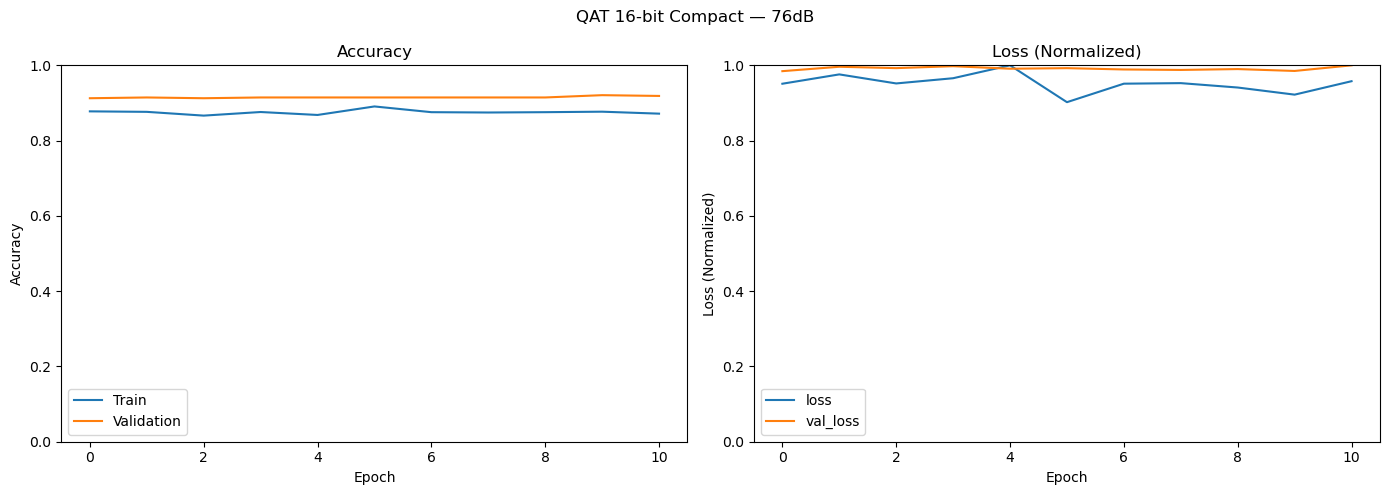


  QAT 8-bit  (int_k=4, int_act=4, LR=0.0001)
  Pre-trained model found: ./ckpt_compact_QAT_8bit_76dB/compact_QAT_8bit_best.h5


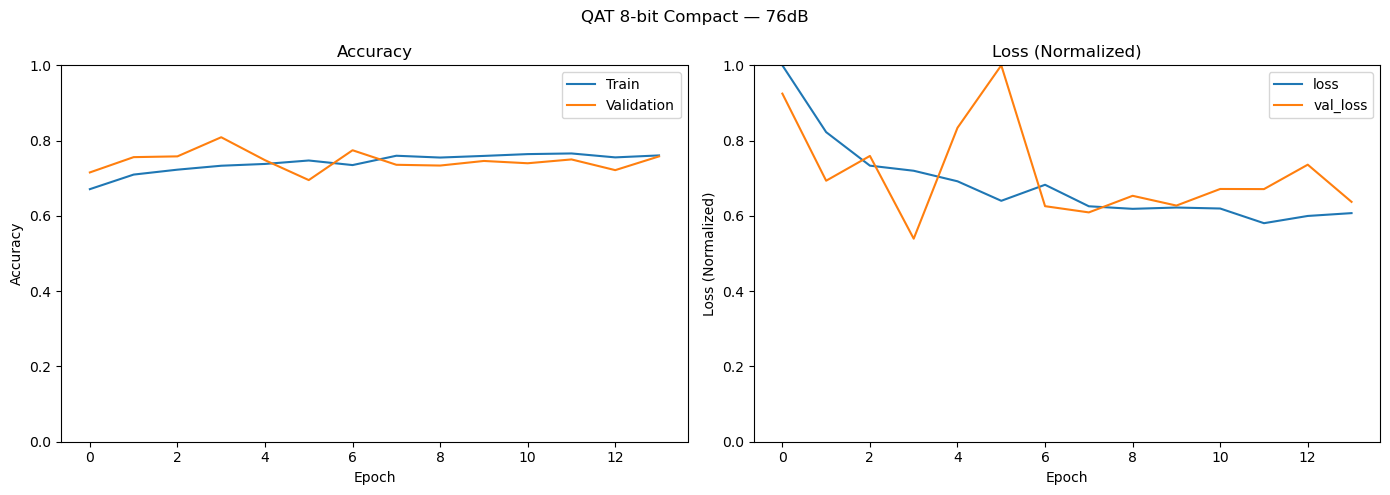


  QAT 4-bit  (int_k=2, int_act=3, LR=0.0005)
  Pre-trained model found: ./ckpt_compact_QAT_4bit_76dB/compact_QAT_4bit_best.h5


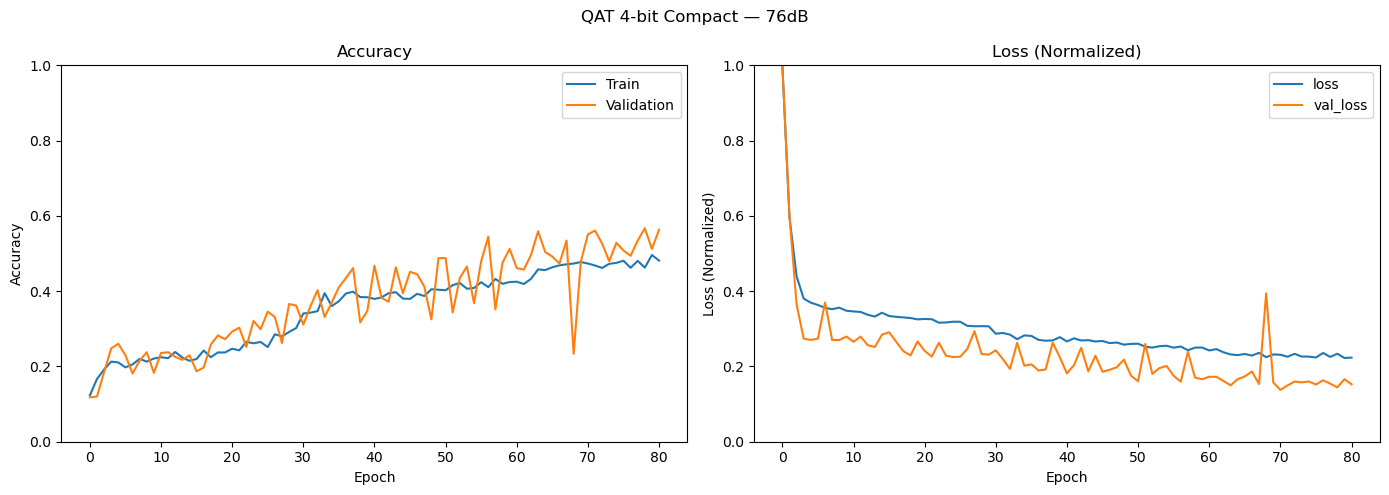


 QAT complete!


In [5]:
# QAT configurations

QAT_CONFIGS = [
    (16, 6, 6, 30,  1e-5),   # 16-bit: fine-tuning suave desde float
    ( 8, 4, 4, 40,  1e-4),   # 8-bit:  paso min ~0.0625, LR 1e-4 → ~62 épocas/step
    ( 4, 2, 3, 500, 5e-4),   # 4-bit:  paso min ~0.25,   LR 5e-4 → ~50 épocas/step
                             #          int_bits_act=3 para rango de activación [0, 7.5]
]

qat_models = {}

for bits, int_bits_k, int_bits_a, ft_epochs, ft_lr in QAT_CONFIGS:
    label     = f'{bits}bit'
    ckpt_dir  = f'./ckpt_compact_QAT_{label}_{TARGET_SNR}'
    best_path = f'{ckpt_dir}/compact_QAT_{label}_best.h5'
    hist_path = f'{ckpt_dir}/compact_QAT_{label}_history.json'
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f'  QAT {bits}-bit  '
          f'(int_k={int_bits_k}, int_act={int_bits_a}, LR={ft_lr})')
    print(f"{'='*60}")

    if os.path.exists(best_path):
        print(f'  Pre-trained model found: {best_path}')
        model_q = tf.keras.models.load_model(
            best_path, custom_objects=QKERAS_CO
        )
        model_q.compile(
            optimizer=Adam(learning_rate=ft_lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    else:
        print('  Building QAT model and transferring float weights...')
        model_q = build_compact_qat_model(
            MFCC_input_shape, NUM_CLASSES, bits, int_bits_k, int_bits_a
        )
        model_q.compile(
            optimizer=Adam(learning_rate=ft_lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        transfer_float_weights(model_compact_float, model_q)

        fresh_early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=max(10, PATIENCE // 2),
            restore_best_weights=True,
            verbose=1
        )

        hist_q = model_q.fit(
            MFCC_dataset_train_batches,
            epochs=ft_epochs,
            validation_data=MFCC_dataset_validation_batches,
            callbacks=[fresh_early_stopping]
        )

        model_q.save(best_path, save_format='h5')
        print(f'  Model saved → {best_path}')
        save_history(hist_q, hist_path)

    if os.path.exists(hist_path):
        plot_training_history(
            load_history(hist_path),
            title=f'QAT {bits}-bit Compact — {TARGET_SNR}'
        )

    qat_models[bits] = model_q

print('\n QAT complete!')


## Model evaluation

In [6]:
all_results = []

# Base float model
loss, acc = model_compact_float.evaluate(
    MFCC_dataset_validation_batches, verbose=0
)
all_results.append({'model': 'Float 32-bit', 'accuracy': acc, 'loss': loss})

# QAT models
for bits in [16, 8, 4]:
    if bits not in qat_models:
        continue
    loss, acc = qat_models[bits].evaluate(
        MFCC_dataset_validation_batches, verbose=0
    )
    all_results.append({
        'model': f'QAT {bits}-bit', 'accuracy': acc, 'loss': loss
    })

print('\n' + '=' * 52)
print(f'{"Model":<20} {"Accuracy":>12} {"Loss":>10}')
print('=' * 52)
for r in all_results:
    print(f"{r['model']:<20} {r['accuracy']:>12.4f} {r['loss']:>10.4f}")
print('=' * 52)



Model                    Accuracy       Loss
Float 32-bit               0.9167     0.3138
QAT 16-bit                 0.9126     0.3166
QAT 8-bit                  0.8089     0.6298
QAT 4-bit                  0.5508     1.1666


## hls4ml: Configuracion Latency + Sintesis

Con la arquitectura BRAM-Opt v2, **todas las capas tienen <= 576 elementos**,
lo que permite usar `Strategy='Latency'` con `ReuseFactor=1`.

### Comparacion de arquitecturas

| Arquitectura | Capa mayor | Elementos | BRAM_18K est. | DSP est. |
|---|---|---|---|---|
| Original | `Dense(128)` | 2 867 200 | 681 FAIL | 932 OK |
| Compacta v1 (20x282) | `Dense(32)` | 3 584 | 681 FAIL | 928 OK |
| **BRAM-Opt v2 (20x64)** | **`Conv2D(8)`** | **576** | **~120 OK** | **~848 OK** |

El cuello de botella era la profundidad de los FIFOs `io_stream`:
`FIFO depth = N_MFCC x MFCC_FRAMES = 20 x 282 = 5640`.
Con 64 frames queda en `20 x 64 = 1280`, reduciendo los BRAMs ~5.7x.


In [7]:
def get_hls_config_compact(keras_model, is_qat=False):
    """
    hls4ml configuration for BRAM-Opt v2 CNN with io_stream.

    KV260 (xck26-sfvc784-2LV-c / ZU5EV):
      BRAM_18K :   288  (144 RAMB36 x 2)
      DSP48E2  : 1,248  (target <= 1,200 conservative)
      CLB LUT  : 117,120
      FF (Reg) : 234,240

    All layers have <= 576 params -> Strategy='Latency' available.

    ReuseFactor per layer (BRAM-Opt v2 architecture, input 20x64):
        conv1 ( 144 MACs): RF=1  ->  144 DSPs
        conv2 ( 576 MACs): RF=4  ->  144 DSPs
        conv3 ( 576 MACs): RF=4  ->  144 DSPs
        dense1( 256 MACs): RF=1  ->  256 DSPs
        output( 160 MACs): RF=1  ->  160 DSPs
        ------------------------------------------
        Estimated total    :        848 DSPs  (68% of 1,248) OK
    """
    config = hls4ml.utils.config_from_keras_model(
        keras_model, granularity='name'
    )
    config['Model']['Strategy']    = 'Latency'
    config['Model']['ReuseFactor'] = 1

    layer_rf = {
        'conv1':  1,    # 144 MACs / 1 = 144 DSPs
        'conv2':  4,    # 576 MACs / 4 = 144 DSPs
        'conv3':  4,    # 576 MACs / 4 = 144 DSPs
        'dense1': 1,    # 256 MACs / 1 = 256 DSPs
        'output': 1,    # 160 MACs / 1 = 160 DSPs
    }
    for lname, rf in layer_rf.items():
        if lname in config.get('LayerName', {}):
            config['LayerName'][lname]['ReuseFactor'] = rf
            config['LayerName'][lname]['Strategy']    = 'Latency'
    return config


def synthesize_compact_model(keras_model, output_dir, label, is_qat=False):
    print(f"\n{'--'*30}")
    print(f'  Synthesizing : {label}')
    print(f'  Directory    : {output_dir}')
    print(f"{'--'*30}")
    config    = get_hls_config_compact(keras_model, is_qat=is_qat)
    hls_model = hls4ml.converters.convert_from_keras_model(
        keras_model,
        hls_config   = config,
        output_dir   = output_dir,
        backend      = 'Vitis',
        part         = FPGA_PART,
        clock_period = CLOCK_PERIOD,
        io_type      = 'io_stream',   # MANDATORY for CNNs
    )
    hls_model.compile()   
    hls_model.build(csim=False, synth=True, cosim=False, export=True)
    print(f'  [OK] Synthesizing completed: {label}')
    return hls_model


def parse_synth_report(output_dir, label):
    """
    Extract latency, timing/Fmax, and resources from the csynth report of Vitis HLS 2023.x.

    Real report format (columns in utilization table):
      | Name | BRAM_18K | DSP | FF | LUT | URAM |
    """
    import re
    rpt = {'model': label}
    candidates = [
        os.path.join(output_dir, 'myproject_prj', 'solution1',
                     'syn', 'report', 'myproject_csynth.rpt'),
        os.path.join(output_dir, 'myproject_prj', 'solution1',
                     'syn', 'report', 'csynth.rpt'),
    ]
    rpt_path = next((p for p in candidates if os.path.exists(p)), None)
    if rpt_path is None:
        return rpt
    content = open(rpt_path).read()

    # -- Timing ---------------------------------------------------------------
    m = re.search(
        r'\|ap_clk\s*\|\s*([\d.]+)\s*ns\s*\|\s*([\d.]+)\s*ns\s*\|\s*([\d.]+)\s*ns\s*\|',
        content
    )
    if m:
        target_ns, estimate_ns = float(m.group(1)), float(m.group(2))
        rpt['clk_target_ns']   = target_ns
        rpt['clk_estimate_ns'] = estimate_ns
        rpt['fmax_mhz']        = round(1000.0 / estimate_ns, 1)
        rpt['timing_met']      = estimate_ns < target_ns

    # -- Latency -------------------------------------------------------------
    lat_start    = content.find('+ Latency:')
    detail_start = content.find('+ Detail:', lat_start)
    if lat_start >= 0:
        lat_region = content[lat_start : detail_start] if detail_start > lat_start \
                     else content[lat_start : lat_start + 1500]
        m = re.search(
            r'\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*([\d.]+)\s*us\s*\|\s*([\d.]+)\s*us\s*\|',
            lat_region
        )
        if m:
            rpt['lat_min_cyc'] = int(m.group(1))
            rpt['lat_max_cyc'] = int(m.group(2))
            rpt['lat_min_us']  = round(float(m.group(3)), 3)
            rpt['lat_max_us']  = round(float(m.group(4)), 3)

    # -- Resources (Utilization Estimates) -------------------------------------
    def _util_row(keyword):
        pat = rf'\|{keyword}\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|'
        m = re.search(pat, content, re.IGNORECASE)
        if m:
            return [int(x) if x.strip() != '-' else None for x in m.groups()]
        return None

    _COL = ['BRAM_18K', 'DSP', 'FF', 'LUT']
    tot = _util_row('Total')
    avl = _util_row('Available')
    pct = _util_row(r'Utilization \(%\)')
    for i, res in enumerate(_COL):
        if tot and tot[i] is not None: rpt[f'{res}_used']  = tot[i]
        if avl and avl[i] is not None: rpt[f'{res}_avail'] = avl[i]
        if pct and pct[i] is not None: rpt[f'{res}_pct']   = pct[i]
    return rpt


# --- Test -----------------------------------
_test_dir = os.path.join(HLS_BASE_DIR, 'float_32')
_test_rpt  = os.path.join(_test_dir, 'myproject_prj', 'solution1',
                           'syn', 'report', 'myproject_csynth.rpt')
if os.path.exists(_test_rpt):
    _r = parse_synth_report(_test_dir, 'Float 32-bit (test)')
    print('Latency: min={lat_min_us} us, max={lat_max_us} us'.format(**_r))
    print('Fmax:     {fmax_mhz} MHz  (estimado {clk_estimate_ns} ns)'.format(**_r))
    print('Timing met:', _r.get('timing_met'))
    print('BRAM_18K: {BRAM_18K_used}/{BRAM_18K_avail} ({BRAM_18K_pct}%)'.format(**_r))
    print('DSP:      {DSP_used}/{DSP_avail} ({DSP_pct}%)'.format(**_r))
else:
    print('Funciones definidas. Ejecutar sintesis para obtener reportes.')


Latency: min=21.855 us, max=21.855 us
Fmax:     250.9 MHz  (estimado 3.985 ns)
Timing met: True
BRAM_18K: 139/288 (48%)
DSP:      796/1248 (63%)


In [8]:
# ─── Preview ─────────────────────────────────────

config_preview = get_hls_config_compact(model_compact_float)

print('hls4ml configuration for compact model:')
print(f"  Global Strategy: {config_preview['Model']['Strategy']}")
print(f"  io_type        : io_stream")
print('  ReuseFactor per layer:')
for lname, lcfg in config_preview.get('LayerName', {}).items():
    rf = lcfg.get('ReuseFactor', '—')
    st = lcfg.get('Strategy', '—')
    if rf != '—' or st != '—':
        print(f'    {lname:20s}: RF={rf}, Strategy={st}')

print('\nConverting model (without synthesis)...')
hls_model_preview = hls4ml.converters.convert_from_keras_model(
    model_compact_float,
    hls_config   = config_preview,
    output_dir   = './hls4ml_preview_compact',
    backend      = 'Vitis',
    part         = FPGA_PART,
    clock_period = CLOCK_PERIOD,
    io_type      = 'io_stream',
)

print('\nLayer sizes:')
verify_layer_sizes(model_compact_float)

try:
    hls4ml.utils.plot_model(
        hls_model_preview, show_shapes=True,
        show_precision=True, to_file=None
    )
except Exception as e:
    print(f'plot_model not available: {e}')


hls4ml configuration for compact model:
  Global Strategy: Latency
  io_type        : io_stream
  ReuseFactor per layer:
    conv1               : RF=1, Strategy=Latency
    conv2               : RF=4, Strategy=Latency
    conv3               : RF=4, Strategy=Latency
    dense1              : RF=1, Strategy=Latency
    output              : RF=1, Strategy=Latency

Converting model (without synthesis)...

Layer sizes:

Verifying layer sizes (limit: 4096)
--------------------------------------------------------------------
  OK         conv1               :     144 elements | shape (3, 3, 2, 8)
  OK         bn1                 :       8 elements | shape (8,)
  OK         conv2               :     576 elements | shape (3, 3, 8, 8)
  OK         bn2                 :       8 elements | shape (8,)
  OK         conv3               :     576 elements | shape (3, 3, 8, 8)
  OK         bn3                 :       8 elements | shape (8,)
  OK         dense1              :     256 elements | shape

In [9]:
# ─── Vitis HLS synthesis ──────────────────────
# Set SYNTHESIZE = True for executing synthesis.

SYNTHESIZE = False 

if SYNTHESIZE:
    os.makedirs(HLS_BASE_DIR, exist_ok=True)
    synth_targets = [
        (model_compact_float,  'float_32',  'Float 32-bit', False),
        (qat_models.get(16),   'qat_16bit', 'QAT 16-bit',   True),
        (qat_models.get(8),    'qat_8bit',  'QAT 8-bit',    True),
        (qat_models.get(4),    'qat_4bit',  'QAT 4-bit',    True),
    ]

    hls_handles   = {}
    synth_reports = []
    for model, subdir, label, is_qat in synth_targets:
        if model is None:
            print(f'  Omitting {label} (model not available)')
            continue
        out_dir = os.path.join(HLS_BASE_DIR, subdir)
        hm = synthesize_compact_model(model, out_dir, label, is_qat=is_qat)
        hls_handles[label]   = hm
        synth_reports.append(parse_synth_report(out_dir, label))

    # Synthesis report table
    import pandas as pd
    df_rpt = pd.DataFrame(synth_reports)
    want   = ['model', 'lat_min_us', 'lat_max_us',
              'LUT_used', 'LUT_pct',
              'FF_used',  'FF_pct',
              'DSP_used', 'DSP_pct',
              'BRAM_18K_used', 'BRAM_18K_pct']
    show   = [c for c in want if c in df_rpt.columns]
    print('\nSynthesis results:')
    print(df_rpt[show].to_string(index=False))
    print(f'\nTarget: {FPGA_PART} @ {1000 // CLOCK_PERIOD} MHz')
    print('IP-XACT packages: <output_dir>/myproject_prj/solution1/impl/ip/')
else:
    print('Synthesis HLS skipped. Set SYNTHESIZE=True to execute.')

Synthesis HLS skipped. Set SYNTHESIZE=True to execute.


## Final summary -- BRAM-Opt v2

### Architecture comparison 

| Aspecto | Original | Compacta v1 | **BRAM-Opt v2** |
|---|---|---|---|
| Input MFCC | (20, 282, 2) | (20, 282, 2) | **(20, 64, 2)** |
| hop_length | 512 (10.7 ms) | 512 (10.7 ms) | **2250 (46.9 ms)** |
| MFCC_FRAMES | 282 | 282 | **64** |
| Filtros Conv | 32->64 | 8->16->16 | **8->8->8** |
| Dense hidden | 128 | 32 | **16** |
| Max. params/capa | 2 867 200 | 3 584 | **576** OK |
| hls4ml Strategy | Resource | Resource | **Latency** OK |
| BRAM_18K est. | 681 FAIL | 681 FAIL | **~120** OK |
| DSP est. | 932 OK | 928 OK | **~848** OK |
| Parametros totales | ~1.5M | ~8K | **~2K** |
| QAT 8-bit LR | 5e-6 (estancado) | 1e-4 | **1e-4** |
| QAT 4-bit LR | 1e-6 (estancado) | 5e-4 | **5e-4** |


In [10]:
# ─── Final table: accuracy + synthesis reports ───────────────────────────────

# ── 1. Accuracy ──────────────────────────────────────────────────────────────
print('╔' + '═'*54 + '╗')
print(f'║ {"ACCURACY / LOSS":^52} ║')
print('╠' + '═'*22 + '╦' + '═'*15 + '╦' + '═'*14 + '╣')
print(f'║ {"Model":<20} ║ {"Accuracy":>13} ║ {"Loss":>12} ║')
print('╠' + '═'*22 + '╬' + '═'*15 + '╬' + '═'*14 + '╣')
for r in all_results:
    print(f"║ {r['model']:<20} ║ {r['accuracy']:>13.4f} ║ {r['loss']:>12.4f} ║")
print('╚' + '═'*22 + '╩' + '═'*15 + '╩' + '═'*14 + '╝')

# ── 2. Synthesis reports ─────────────────────────────────────────────────────
_synth_dirs = [
    ('Float 32-bit', os.path.join(HLS_BASE_DIR, 'float_32')),
    ('QAT 16-bit',   os.path.join(HLS_BASE_DIR, 'qat_16bit')),
    ('QAT 8-bit',    os.path.join(HLS_BASE_DIR, 'qat_8bit')),
    ('QAT 4-bit',    os.path.join(HLS_BASE_DIR, 'qat_4bit')),
]
_reports = [parse_synth_report(d, lbl) for lbl, d in _synth_dirs]
_ok = [r for r in _reports if len(r) > 1]

if _ok:
    # ── Latency + Timing ────────────────────────────────────────────────────
    print()
    W = 88
    print('╔' + '═'*(W-2) + '╗')
    print(f'║ {"LATENCY AND TIMING":^{W-4}} ║')
    print('╠' + '═'*(W-2) + '╣')
    print(f'║ {"Model":<16}  {"Lat min":>9}  {"Lat max":>9}  {"Fmax":>9}  {"Clk est":>9}  {"Target":>7}  {"Timing":^8} ║')
    print(f'║ {"":16}  {"(µs)":>9}  {"(µs)":>9}  {"(MHz)":>9}  {"(ns)":>9}  {"(ns)":>7}  {"":8} ║')
    print('╠' + '═'*(W-2) + '╣')
    for r in _ok:
        lat_min = f"{r['lat_min_us']:9.3f}" if 'lat_min_us' in r else f'{"—":>9}'
        lat_max = f"{r['lat_max_us']:9.3f}" if 'lat_max_us' in r else f'{"—":>9}'
        fmax    = f"{r['fmax_mhz']:9.1f}"  if 'fmax_mhz'   in r else f'{"—":>9}'
        est     = f"{r['clk_estimate_ns']:9.3f}" if 'clk_estimate_ns' in r else f'{"—":>9}'
        tgt     = f"{r['clk_target_ns']:7.2f}"  if 'clk_target_ns'   in r else f'{"—":>7}'
        sym     = '✅ MET  ' if r.get('timing_met') else ('❌ FAIL ' if 'timing_met' in r else '—       ')
        print(f'║ {r["model"]:<16}  {lat_min}  {lat_max}  {fmax}  {est}  {tgt}  {sym} ║')
    print('╚' + '═'*(W-2) + '╝')

    # ── Resources ─────────────────────────────────────────────────────────────
    print()
    KV260 = {'LUT': 117120, 'FF': 234240, 'DSP': 1248, 'BRAM_18K': 288}
    W2 = 92
    print('╔' + '═'*(W2-2) + '╗')
    print(f'║ {"RESOURCES (Vitis HLS csynth — pre-P&R estimation)":^{W2-4}} ║')
    print('╠' + '═'*(W2-2) + '╣')
    print(f'║ {"Model":<16}  {"LUT":>9} {"LUT%":>6}  {"FF":>9} {"FF%":>5}  {"DSP":>6} {"DSP%":>6}  {"BRAM_18K":>9} {"BRAM%":>6} ║')
    print('╠' + '═'*(W2-2) + '╣')
    for r in _ok:
        lu = f"{r.get('LUT_used',  '—'):>9}";  lup = f"{r.get('LUT_pct',       '—'):>5}%"
        ff = f"{r.get('FF_used',   '—'):>9}";  ffp = f"{r.get('FF_pct',        '—'):>4}%"
        ds = f"{r.get('DSP_used',  '—'):>6}";  dsp = f"{r.get('DSP_pct',       '—'):>5}%"
        br = f"{r.get('BRAM_18K_used','—'):>9}"; brp_v = r.get('BRAM_18K_pct', 0)
        brp_str = f"{brp_v:>5}%"
        warn = ' ⚠️ ' if isinstance(brp_v, (int,float)) and brp_v > 100 else '    '
        print(f'║ {r["model"]:<16}  {lu} {lup}  {ff} {ffp}  {ds} {dsp}  {br} {brp_str}{warn}║')
    print('╠' + '═'*(W2-2) + '╣')
    print(f'║ {"KV260 available":<16}  {KV260["LUT"]:>9} {"100%":>6}  {KV260["FF"]:>9} {"100%":>5}  '
          f'{KV260["DSP"]:>6} {"100%":>6}  {KV260["BRAM_18K"]:>9} {"100%":>6}     ║')
    print('╚' + '═'*(W2-2) + '╝')

    # ── Alerta BRAM ──────────────────────────────────────────────────────────
    _bram_vals = [r.get('BRAM_18K_pct', 0) for r in _ok if 'BRAM_18K_pct' in r]
    if any(v > 100 for v in _bram_vals):
        print()
        print('⚠️ BRAM ALERT: one or more designs exceed 100% of available BRAM.')
        print('   Designs with BRAM > 100% will fail Place & Route (P&R) in Vivado.')

    print(f'\nTarget: {FPGA_PART} @ {1000//CLOCK_PERIOD} MHz')
else:
    print('⚠️  Resources not found. Execute synthesis (SYNTHESIZE=True).')

# ── 3. Layer sizes ────────────────────────────────────────────────────────
print()
print('─── Layer size verification (all must be ≤ 4096) ───')
verify_layer_sizes(model_compact_float)
total_w = sum(int(np.prod(l.get_weights()[0].shape))
              for l in model_compact_float.layers if l.get_weights())
print(f'\nTotal weight parameters: {total_w:,}')


╔══════════════════════════════════════════════════════╗
║                   ACCURACY / LOSS                    ║
╠══════════════════════╦═══════════════╦══════════════╣
║ Model                ║      Accuracy ║         Loss ║
╠══════════════════════╬═══════════════╬══════════════╣
║ Float 32-bit         ║        0.9167 ║       0.3138 ║
║ QAT 16-bit           ║        0.9126 ║       0.3166 ║
║ QAT 8-bit            ║        0.8089 ║       0.6298 ║
║ QAT 4-bit            ║        0.5508 ║       1.1666 ║
╚══════════════════════╩═══════════════╩══════════════╝

╔══════════════════════════════════════════════════════════════════════════════════════╗
║                                  LATENCY AND TIMING                                  ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ Model               Lat min    Lat max       Fmax    Clk est   Target   Timing  ║
║                        (µs)       (µs)      (MHz)       (ns)     (ns)           ║
╠═

## AXI Stream Wrapper — QAT Model Modifications

The float32 HLS project was manually updated to expose an AXI Stream interface (`myproject_axi`).
The same modification has been applied to all three QAT models:

| Model | Modified files | Stream param name |
|-------|---------------|-------------------|
| float_32  | `firmware/myproject_axi.h`, `firmware/myproject_axi.cpp`, `build_prj.tcl` | `input_4` |
| qat_16bit | same | `input_5` |
| qat_8bit  | same | `input_6` |
| qat_4bit  | same | `input_8` |

`build_prj.tcl` changes per QAT model:
- `set_top` → `myproject_axi`
- `add_files firmware/myproject_axi.cpp` added

Run the verification cell below to confirm all files are in place, then run QAT HLS synthesis.

In [11]:

# ============================================================
# QAT AXI SYNTHESIS  —  Vitis HLS (synth + export)
# ============================================================
# Runs Vitis HLS synthesis on each QAT model directory, which
# now contains the AXI Stream wrapper (myproject_axi.cpp/.h)
# and an updated build_prj.tcl with set_top myproject_axi.
#
# Set RUN_QAT_HLS = True to execute.  Each model takes ~20 min.
# Logs are saved to <model_dir>/hls_synth.log

import subprocess, shutil

RUN_QAT_HLS = False

QAT_HLS_TARGETS = [
    ('qat_16bit', 'QAT 16-bit'),
    ('qat_8bit',  'QAT 8-bit'),
    ('qat_4bit',  'QAT 4-bit'),
]

HLS_BASE_DIR = './hls4ml_output_compact'

def run_vitis_hls(model_dir, label):
    """Run Vitis HLS synthesis in model_dir. Returns (success, log_path, err_msg)."""
    vitis_hls = shutil.which('vitis_hls')
    if vitis_hls is None:
        return False, None, 'vitis_hls not found in PATH'
    
    log_path = os.path.join(model_dir, 'hls_synth.log')
    cmd = [vitis_hls, 'build_prj.tcl']
    
    print(f'  Running: {" ".join(cmd)}')
    print(f'  Working dir: {model_dir}')
    print(f'  Log: {log_path}')
    
    try:
        with open(log_path, 'w') as log_f:
            proc = subprocess.run(
                cmd,
                cwd=model_dir,
                stdout=log_f,
                stderr=subprocess.STDOUT,
                timeout=7200   # 2 h hard limit
            )
        success = proc.returncode == 0
        return success, log_path, None
    except subprocess.TimeoutExpired:
        return False, log_path, 'Synthesis timed out (>2 h)'
    except Exception as e:
        return False, log_path, str(e)

if RUN_QAT_HLS:
    for subdir, label in QAT_HLS_TARGETS:
        model_dir = os.path.join(HLS_BASE_DIR, subdir)
        print(f'\n{"="*60}')
        print(f'HLS Synthesis: {label}')
        print(f'{"="*60}')
        
        axi_h   = os.path.join(model_dir, 'firmware', 'myproject_axi.h')
        axi_cpp = os.path.join(model_dir, 'firmware', 'myproject_axi.cpp')
        if not (os.path.exists(axi_h) and os.path.exists(axi_cpp)):
            print(f'  ERROR: AXI wrapper files missing in {model_dir}/firmware/')
            continue
        
        success, log_path, err_msg = run_vitis_hls(model_dir, label)
        
        if err_msg:
            print(f'  ERROR: {err_msg}')
        elif success:
            print(f'  SUCCESS — IP exported to:')
            print(f'    {model_dir}/myproject_prj/solution1/impl/ip/')
        else:
            print(f'  FAILED — check log: {log_path}')
            if log_path and os.path.exists(log_path):
                with open(log_path) as f:
                    lines = f.readlines()
                print('  Last 30 log lines:')
                for line in lines[-30:]:
                    print(f'    {line}', end='')
else:
    print('QAT HLS synthesis skipped.  Set RUN_QAT_HLS = True to run.')
    print()
    print('Expected output structure after synthesis:')
    for subdir, label in QAT_HLS_TARGETS:
        ip_path = os.path.join(HLS_BASE_DIR, subdir, 'myproject_prj/solution1/impl/ip')
        exists  = '✅ exists' if os.path.isdir(ip_path) else '⬜ not yet synthesized'
        print(f'  {label:12s}  {ip_path}  [{exists}]')


QAT HLS synthesis skipped.  Set RUN_QAT_HLS = True to run.

Expected output structure after synthesis:
  QAT 16-bit    ./hls4ml_output_compact/qat_16bit/myproject_prj/solution1/impl/ip  [✅ exists]
  QAT 8-bit     ./hls4ml_output_compact/qat_8bit/myproject_prj/solution1/impl/ip  [✅ exists]
  QAT 4-bit     ./hls4ml_output_compact/qat_4bit/myproject_prj/solution1/impl/ip  [✅ exists]


In [12]:

# ============================================================
# VALIDATE QAT IP INTERFACES VS FLOAT32 REFERENCE
# ============================================================
# After HLS synthesis + export, compare the AXI port definitions
# in each QAT IP against the float32 IP as the reference.

import xml.etree.ElementTree as ET
import glob

def get_ip_ports(ip_dir):
    """Parse component.xml from an exported HLS IP to extract port info."""
    comp_xml = os.path.join(ip_dir, 'component.xml')
    if not os.path.exists(comp_xml):
        return None, f"component.xml not found at {comp_xml}"
    
    tree = ET.parse(comp_xml)
    root = tree.getroot()
    ns = {'spirit': 'http://www.spiritconsortium.org/XMLSchema/SPIRIT/1685-2009'}
    
    ports = {}
    bus_ifaces = root.findall('.//spirit:busInterface', ns)
    for iface in bus_ifaces:
        name_el = iface.find('spirit:name', ns)
        bus_type_el = iface.find('spirit:busType', ns)
        if name_el is not None and bus_type_el is not None:
            name = name_el.text
            vendor = bus_type_el.get('{http://www.spiritconsortium.org/XMLSchema/SPIRIT/1685-2009}vendor', '')
            lib = bus_type_el.get('{http://www.spiritconsortium.org/XMLSchema/SPIRIT/1685-2009}library', '')
            btype = bus_type_el.get('{http://www.spiritconsortium.org/XMLSchema/SPIRIT/1685-2009}name', '')
            version = bus_type_el.get('{http://www.spiritconsortium.org/XMLSchema/SPIRIT/1685-2009}version', '')
            ports[name] = f"{vendor}:{lib}:{btype}:{version}"
    
    return ports, None

HLS_BASE_DIR = './hls4ml_output_compact'
MODELS = {
    'float_32':  'float_32',
    'qat_16bit': 'qat_16bit',
    'qat_8bit':  'qat_8bit',
    'qat_4bit':  'qat_4bit',
}

print("=" * 70)
print("IP Interface Validation: QAT Models vs Float32 Reference")
print("=" * 70)

ref_ip_dir  = os.path.join(HLS_BASE_DIR, 'float_32', 'myproject_prj', 'solution1', 'impl', 'ip')
ref_ports, ref_err = get_ip_ports(ref_ip_dir)

if ref_err:
    print(f"⚠  Float32 reference IP not found: {ref_err}")
    print("   Run float32 HLS synthesis first.")
else:
    print(f"\n✅ Float32 reference ports:")
    for pname, ptype in sorted(ref_ports.items()):
        print(f"   {pname:30s} → {ptype}")

print()
all_pass = True
for label, subdir in list(MODELS.items())[1:]:  # skip float_32
    ip_dir = os.path.join(HLS_BASE_DIR, subdir, 'myproject_prj', 'solution1', 'impl', 'ip')
    
    ports, err = get_ip_ports(ip_dir)
    if err:
        print(f"⚠  {label}: IP not yet synthesized — {err}")
        all_pass = False
        continue
    
    missing  = set(ref_ports.keys()) - set(ports.keys()) if ref_ports else set()
    extra    = set(ports.keys()) - set(ref_ports.keys()) if ref_ports else set()
    mismatch = {k for k in (set(ref_ports.keys()) & set(ports.keys())) if ref_ports[k] != ports[k]} if ref_ports else set()
    
    if not missing and not extra and not mismatch:
        print(f"✅ {label}: interface matches float32 reference")
    else:
        print(f"❌ {label}: interface differences detected!")
        for k in missing:
            print(f"     MISSING port: {k}")
        for k in extra:
            print(f"     EXTRA port:   {k} → {ports[k]}")
        for k in mismatch:
            print(f"     MISMATCH:     {k}  ref={ref_ports[k]}  got={ports[k]}")
        all_pass = False

print()
if all_pass:
    print("✅ All synthesized QAT IPs match the float32 AXI interface.")
else:
    print("⚠  Some IPs are not yet synthesized or have interface differences.")
    print("   Run QAT HLS synthesis cell above first, then re-run this cell.")


IP Interface Validation: QAT Models vs Float32 Reference

✅ Float32 reference ports:
   ap_clk                         → xilinx.com:signal:clock:1.0
   ap_rst_n                       → xilinx.com:signal:reset:1.0
   in_stream                      → xilinx.com:interface:axis:1.0
   out_stream                     → xilinx.com:interface:axis:1.0

✅ qat_16bit: interface matches float32 reference
✅ qat_8bit: interface matches float32 reference
✅ qat_4bit: interface matches float32 reference

✅ All synthesized QAT IPs match the float32 AXI interface.


## Bitfile Generation for All Models

This section creates Vivado projects and generates bitstreams for all trained models.
The process assumes HLS synthesis is already complete (see cells above).

The process:
1. HLS IPs already synthesized via Vitis HLS (see synthesis cells above)
2. Each model gets its own Vivado project with the correct HLS IP repo added
3. The block design (`scripts/design_1.tcl`) is shared — all models expose the same `myproject_axi:1.0` VLNV
4. Implementation and bitstream generation runs per model

In [13]:
# ============================================================
# BITFILE GENERATION UTILITIES
# ============================================================
# Vivado-only flow: HLS IPs are already synthesized via Vitis HLS.
# Each model gets its own Vivado project.  All projects share the
# same block design TCL (scripts/design_1.tcl), which was exported
# from the manually-built float32 Vivado project.  Because each
# project adds only its own HLS IP repo before sourcing the BD TCL,
# Vivado resolves xilinx.com:hls:myproject_axi:1.0 to the correct IP.

import subprocess
import os

FPGA_PART   = 'xck26-sfvc784-2LV-c'
BOARD_PART  = 'xilinx.com:kv260_som:part0:1.4'
BD_TCL_PATH = os.path.abspath('scripts/design_1.tcl')
VIVADO_BIN  = '/tools/Xilinx/Vivado/2023.2/bin/vivado'


def generate_vivado_tcl(output_dir, project_name, ip_repo_path):
    """
    Write a Vivado batch TCL script that:
      1. Creates a new project for the KV260 (xck26-sfvc784-2LV-c)
      2. Adds the model-specific HLS IP repository
      3. Sources scripts/design_1.tcl to recreate the block design
      4. Creates the HDL wrapper
      5. Runs implementation through write_bitstream
      6. Copies the .bit and .hwh to output_dir/
    """
    ip_repo_abs  = os.path.abspath(ip_repo_path)
    output_abs   = os.path.abspath(output_dir)
    bd_tcl_abs   = BD_TCL_PATH

    tcl = f"""\
# Vivado batch script — KV260 Speaker Recognition Accelerator
# Auto-generated by MFCC_CNN_hls4ml_compact.ipynb

set project_name  "{project_name}"
set output_dir    "{output_abs}"
set ip_repo       "{ip_repo_abs}"
set bd_tcl        "{bd_tcl_abs}"

# ── 1. Create project ────────────────────────────────────────
create_project $project_name $output_dir/$project_name -part {FPGA_PART}
set_property BOARD_PART {BOARD_PART} [current_project]

# ── 2. Add model-specific HLS IP repo ────────────────────────
set_property ip_repo_paths [list $ip_repo] [current_project]
update_ip_catalog

# ── 3. Recreate block design ─────────────────────────────────
# design_1.tcl checks for an open project and skips project
# creation, so it proceeds straight to building the BD.
source $bd_tcl

# ── 4. Create HDL wrapper ────────────────────────────────────
set bd_file [get_files design_1.bd]
make_wrapper -files [list $bd_file] -top
set wrapper $output_dir/$project_name/$project_name.gen/sources_1/bd/design_1/hdl/design_1_wrapper.v
add_files -norecurse $wrapper
update_compile_order -fileset sources_1

# ── 5. Run implementation to bitstream ───────────────────────
launch_runs impl_1 -to_step write_bitstream -jobs 1
wait_on_run impl_1

# ── 6. Copy outputs ──────────────────────────────────────────
set runs_dir  $output_dir/$project_name/$project_name.runs/impl_1
set hwh_dir   $output_dir/$project_name/$project_name.gen/sources_1/bd/design_1/hw_handoff

if {{[file exists $runs_dir/design_1_wrapper.bit]}} {{
    file copy -force $runs_dir/design_1_wrapper.bit $output_dir/design_1_wrapper.bit
    file copy -force $hwh_dir/design_1.hwh          $output_dir/design_1.hwh
    puts "SUCCESS: $output_dir/design_1_wrapper.bit"
}} else {{
    puts "ERROR: Bitstream not found — check impl_1 run status"
    puts "  [get_property STATUS   [get_runs impl_1]]"
    puts "  [get_property PROGRESS [get_runs impl_1]]"
}}

close_project
"""
    os.makedirs(output_dir, exist_ok=True)
    tcl_path = os.path.join(output_dir, 'build_vivado.tcl')
    with open(tcl_path, 'w') as f:
        f.write(tcl)
    return tcl_path


def run_vivado_bitstream(tcl_path, vivado_path=VIVADO_BIN):
    """Run Vivado in batch mode. Streams last 40 log lines to stdout on error."""
    log_path = tcl_path.replace('.tcl', '.log')
    cmd = [vivado_path, '-mode', 'batch', '-source', tcl_path,
           '-notrace','-log', log_path, '-journal', log_path.replace('.log', '.jou')]
    print(f"Running: {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("Vivado returned non-zero exit code.")
        if os.path.exists(log_path):
            with open(log_path) as f:
                lines = f.readlines()
            print("Last 40 log lines:")
            print(''.join(lines[-40:]))
    return result.returncode == 0


# Sanity check
print(f"FPGA part    : {FPGA_PART}")
print(f"Block design : {BD_TCL_PATH}")
print(f"BD TCL exists: {os.path.exists(BD_TCL_PATH)}")
print(f"Vivado bin   : {VIVADO_BIN}  (exists: {os.path.exists(VIVADO_BIN)})")


FPGA part    : xck26-sfvc784-2LV-c
Block design : /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/scripts/design_1.tcl
BD TCL exists: True
Vivado bin   : /tools/Xilinx/Vivado/2023.2/bin/vivado  (exists: True)


### Bitfile Generation - Float 32-bit Model

In [ ]:
# ============================================================
# BITFILE GENERATION — FLOAT32 MODEL
# ============================================================
# HLS IP is already at:
#   hls4ml_output_compact/float_32/myproject_prj/solution1/impl/ip/
#
# Set RUN_VIVADO_FLOAT32 = True to launch Vivado (~30–90 min).
# Set to False to only write the TCL script for manual execution.

RUN_VIVADO_FLOAT32 = True

FLOAT32_IP_REPO  = os.path.abspath('hls4ml_output_compact/float_32/myproject_prj/solution1/impl/ip')
FLOAT32_OUT_DIR  = os.path.abspath('bitfiles/float32')

print(f"Float32 IP repo : {FLOAT32_IP_REPO}")
print(f"IP repo exists  : {os.path.exists(FLOAT32_IP_REPO)}")
print(f"Output dir      : {FLOAT32_OUT_DIR}")

tcl_path = generate_vivado_tcl(
    output_dir   = FLOAT32_OUT_DIR,
    project_name = 'vivado_float32',
    ip_repo_path = FLOAT32_IP_REPO,
)
print(f"\nTCL script written: {tcl_path}")

if RUN_VIVADO_FLOAT32:
    print("\nRunning Vivado implementation (30–90 min) ...")
    success = run_vivado_bitstream(tcl_path)
    if success:
        print(f"\n✅ Float32 bitstream: {FLOAT32_OUT_DIR}/design_1_wrapper.bit")
    else:
        print(f"\n❌ Failed. Check log: {tcl_path.replace('.tcl', '.log')}")
else:
    print(f"\nRUN_VIVADO_FLOAT32 = False.  To build manually:")
    print(f"  vivado -mode batch -source {tcl_path} -notrace")


Float32 IP repo : /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/hls4ml_output_compact/float_32/myproject_prj/solution1/impl/ip
IP repo exists  : True
Output dir      : /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/bitfiles/float32

TCL script written: /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/bitfiles/float32/build_vivado.tcl

Running Vivado implementation (30–90 min) ...
Running: /tools/Xilinx/Vivado/2023.2/bin/vivado -mode batch -source /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/bitfiles/float32/build_vivado.tcl -notrace -log /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/bitfiles/float32/build_vivado.log -journal /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/bitfiles/float32/build_vivado.jou


### Bitfile Generation - QAT Models (16-bit, 8-bit, 4-bit)

In [ ]:
# ============================================================
# BITFILE GENERATION — QAT MODELS (16-bit, 8-bit, 4-bit)
# ============================================================
# Each model gets its own Vivado project; they all share
# scripts/design_1.tcl but point to different HLS IP repos.
#
# Requires QAT HLS synthesis to be complete first.
# Set RUN_VIVADO_QAT = True to launch Vivado for all models.

RUN_VIVADO_QAT = True

QAT_VIVADO_TARGETS = [
    ('qat_16bit', 'hls4ml_output_compact/qat_16bit/myproject_prj/solution1/impl/ip', 'bitfiles/qat_16bit'),
    ('qat_8bit',  'hls4ml_output_compact/qat_8bit/myproject_prj/solution1/impl/ip',  'bitfiles/qat_8bit'),
    ('qat_4bit',  'hls4ml_output_compact/qat_4bit/myproject_prj/solution1/impl/ip',  'bitfiles/qat_4bit'),
]

for label, ip_repo_rel, out_dir_rel in QAT_VIVADO_TARGETS:
    ip_repo = os.path.abspath(ip_repo_rel)
    out_dir = os.path.abspath(out_dir_rel)

    print(f"\n{'='*60}")
    print(f"  {label.upper()}")
    print(f"{'='*60}")
    print(f"  IP repo : {ip_repo}")
    print(f"  Exists  : {os.path.exists(ip_repo)}")

    if not os.path.exists(ip_repo):
        print(f"  SKIP — run QAT HLS synthesis cell above first")
        continue

    tcl_path = generate_vivado_tcl(
        output_dir   = out_dir,
        project_name = f'vivado_{label}',
        ip_repo_path = ip_repo,
    )
    print(f"  TCL     : {tcl_path}")

    if RUN_VIVADO_QAT:
        print(f"  Running Vivado implementation (30–90 min) ...")
        success = run_vivado_bitstream(tcl_path)
        if success:
            print(f"  ✅ Bitstream: {out_dir}/design_1_wrapper.bit")
        else:
            print(f"  ❌ Failed. Check: {tcl_path.replace('.tcl', '.log')}")
    else:
        print(f"  To build manually:")
        print(f"    vivado -mode batch -source {tcl_path} -notrace")

print(f"\n{'='*60}")
print("Summary — expected bitfile locations:")
for label, _, out_dir_rel in QAT_VIVADO_TARGETS:
    bit = os.path.join(out_dir_rel, 'design_1_wrapper.bit')
    status = '✅' if os.path.exists(bit) else '⬜'
    print(f"  {status}  {bit}")



  QAT_16BIT
  IP repo : /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/hls4ml_output_compact/qat_16bit/myproject_prj/solution1/impl/ip
  Exists  : True
  TCL     : /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/bitfiles/qat_16bit/build_vivado.tcl
  Running Vivado implementation (30–90 min) ...
Running: /tools/Xilinx/Vivado/2023.2/bin/vivado -mode batch -source /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/bitfiles/qat_16bit/build_vivado.tcl -notrace -log /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/bitfiles/qat_16bit/build_vivado.log -journal /home/chejimenez/GitHub/NBFM_SpeakerRecognition_FPGA_Accelerator/bitfiles/qat_16bit/build_vivado.jou



## KV260 PYNQ Drivers

Four driver files are provided in [`drivers/`](drivers/), one per model.
Copy the entire `drivers/` folder to the KV260 alongside the bitfiles.

### Driver summary

| Model | Driver file | Class | Accuracy | Buffer (in) |
|-------|-------------|-------|----------|-------------|
| Float32 | `drivers/driver_float32.py` | `SpeakerRecogFloat32Overlay` | 91.67 % | (2560,) uint32 † |
| QAT 16-bit | `drivers/driver_qat_16bit.py` | `SpeakerRecogQAT16Overlay` | 91.26 % | (1280,) uint32 |
| QAT 8-bit | `drivers/driver_qat_8bit.py` | `SpeakerRecogQAT8Overlay` | 80.89 % | (1280,) uint32 |
| QAT 4-bit | `drivers/driver_qat_4bit.py` | `SpeakerRecogQAT4Overlay` | 55.08 % | (1280,) uint32 |

† The float32 HLS wrapper has an internal loop count of 2560 (instead of the correct 1280 used by the QAT wrappers). The float32 driver compensates by padding the buffer with 1280 zero words. The AXI port interface is identical for all models.

### I/O encoding (all models)

All models share the same external fixed-point encoding:

```
I/O type : ap_fixed<16,6>  (W=16, I=6, F=10)

encode(x_float) = int16(round(x * 2**10))   # scale = 1024
decode(y_int16) = y * 2**-10
```

Input packing per 32-bit DMA word:
```
bits[15: 0] = ch0  (MFCC channel 0, ap_fixed<16,6> as uint16 bit pattern)
bits[31:16] = ch1  (MFCC channel 1, ap_fixed<16,6> as uint16 bit pattern)
```

### Usage on KV260 (PYNQ)

```python
import numpy as np
from drivers.driver_qat_16bit import SpeakerRecogQAT16Overlay

# Load bitstream (downloads to PL automatically)
overlay = SpeakerRecogQAT16Overlay('bitfiles/qat_16bit/design_1_wrapper.bit')

# mfcc_sample : (20, 64, 2) float32  — one MFCC feature map
scores  = overlay.predict(mfcc_sample)            # (10,) float32 softmax scores
speaker = overlay.predict_class(mfcc_sample)      # int 0-9

# With timing
scores, dt, rate = overlay.predict(mfcc_sample, profile=True)
```

### Required bitfile structure

```
KV260 filesystem:
  bitfiles/
    float32/          design_1_wrapper.bit   design_1_wrapper.hwh
    qat_16bit/        design_1_wrapper.bit   design_1_wrapper.hwh
    qat_8bit/         design_1_wrapper.bit   design_1_wrapper.hwh
    qat_4bit/         design_1_wrapper.bit   design_1_wrapper.hwh
  drivers/
    driver_float32.py
    driver_qat_16bit.py
    driver_qat_8bit.py
    driver_qat_4bit.py
```


In [14]:

# ============================================================
# EXPORT TEST DATASET AS .npy  (for KV260 / part-7b style deployment)
# ============================================================
# The hls4ml tutorial part7b uses plain NumPy .npy files.
# Our datasets are stored as tf.data.Dataset snapshots.
# This cell extracts test data + Keras predictions → kria_package/

import os, pickle
import numpy as np
import tensorflow as tf

KRIA_PKG_DIR  = 'kria_package'
DATASETS_PATH = 'MFCC_datasets'

os.makedirs(KRIA_PKG_DIR, exist_ok=True)

# ── 1. Load element_spec (any split works — same schema for all) ──────────
SPEC_PATH = os.path.join(DATASETS_PATH, 'element_spec.pkl')
with open(SPEC_PATH, 'rb') as f:
    specs = pickle.load(f)

# Prefer 'test' key, fall back to first available key
_spec_key = 'test' if 'test' in specs else next(iter(specs))
elem_spec = specs[_spec_key]
print(f'Using element_spec key: "{_spec_key}"')

# ── 2. Load test split (prefer test_batches, fall back to validation_batches) ──
test_dir = os.path.join(DATASETS_PATH, 'test_batches')
val_dir  = os.path.join(DATASETS_PATH, 'validation_batches')

if os.path.isdir(test_dir):
    src_ds  = tf.data.Dataset.load(test_dir, element_spec=elem_spec).prefetch(tf.data.AUTOTUNE)
    src_lbl = 'test_batches'
else:
    src_ds  = tf.data.Dataset.load(val_dir, element_spec=elem_spec).prefetch(tf.data.AUTOTUNE)
    src_lbl = 'validation_batches (test_batches not found)'

print(f'Source dataset: {src_lbl}')

# ── 3. Unbatch → numpy arrays ─────────────────────────────────────────────
X_list, y_list = [], []
for bX, by in src_ds:
    X_list.append(bX.numpy())
    y_list.append(by.numpy())

X_test = np.concatenate(X_list, axis=0).astype(np.float32)  # (N, 20, 64, 2)
y_test = np.concatenate(y_list, axis=0).astype(np.int32)     # (N,) int class index

print(f'\nExtracted:')
print(f'  X_test : {X_test.shape}  dtype={X_test.dtype}')
print(f'  y_test : {y_test.shape}  dtype={y_test.dtype}')
print(f'  Class distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}')

# ── 4. Save X_test, y_test, classes ──────────────────────────────────────
np.save(os.path.join(KRIA_PKG_DIR, 'X_test.npy'), X_test)
np.save(os.path.join(KRIA_PKG_DIR, 'y_test.npy'), y_test)

classes = np.array(subfolders, dtype=str)           # e.g. ['f0001', ..., 'm0005']
np.save(os.path.join(KRIA_PKG_DIR, 'classes.npy'), classes)
print(f'\nSaved: X_test.npy, y_test.npy, classes.npy  →  {KRIA_PKG_DIR}/')

# ── 5. Save Keras softmax predictions (host-side reference for validation) ──
_models_export = [('float32', model_compact_float)]
for bits in [16, 8, 4]:
    if bits in qat_models:
        _models_export.append((f'qat{bits}bit', qat_models[bits]))

print('\nGenerating Keras (CPU) reference predictions:')
for name, m in _models_export:
    y_pred = m.predict(X_test, batch_size=64, verbose=0)   # (N, 10) softmax
    out_path = os.path.join(KRIA_PKG_DIR, f'y_keras_{name}.npy')
    np.save(out_path, y_pred.astype(np.float32))
    acc = np.mean(np.argmax(y_pred, axis=1) == y_test)
    print(f'  {name:12s}  acc={acc:.4f}  → {out_path}')

# ── 6. Summary ────────────────────────────────────────────────────────────
print(f'\nkria_package/ contents:')
for fname in sorted(os.listdir(KRIA_PKG_DIR)):
    sz_kb = os.path.getsize(os.path.join(KRIA_PKG_DIR, fname)) / 1024
    print(f'  {fname:<40s}  {sz_kb:7.1f} KB')

print(f"""
Transfer to KV260:
  scp -r kria_package/ drivers/ kria@<kv260-ip>:~/speaker_recog/
""")


Using element_spec key: "test"
Source dataset: test_batches

Extracted:
  X_test : (493, 20, 64, 2)  dtype=float32
  y_test : (493,)  dtype=int32
  Class distribution: {0: 33, 1: 39, 2: 55, 3: 64, 4: 73, 5: 52, 6: 53, 7: 56, 8: 27, 9: 41}

Saved: X_test.npy, y_test.npy, classes.npy  →  kria_package/

Generating Keras (CPU) reference predictions:
  float32       acc=0.9026  → kria_package/y_keras_float32.npy
  qat16bit      acc=0.9067  → kria_package/y_keras_qat16bit.npy
  qat8bit       acc=0.7890  → kria_package/y_keras_qat8bit.npy
  qat4bit       acc=0.5375  → kria_package/y_keras_qat4bit.npy

kria_package/ contents:
  X_test.npy                                 4930.1 KB
  classes.npy                                   0.3 KB
  y_keras_float32.npy                          19.4 KB
  y_keras_qat16bit.npy                         19.4 KB
  y_keras_qat4bit.npy                          19.4 KB
  y_keras_qat8bit.npy                          19.4 KB
  y_test.npy                                


## Export Test Dataset for KV260 Deployment

The hls4ml tutorial (part 7b) expects plain NumPy `.npy` files on the target board.  
Our datasets are stored as `tf.data.Dataset` snapshots — this cell converts them.

Files created in `kria_package/`:

| File | Shape | Description |
|------|-------|-------------|
| `X_test.npy` | `(N, 20, 64, 2)` float32 | MFCC feature maps |
| `y_test.npy` | `(N,)` int32 | Ground-truth class indices 0–9 |
| `classes.npy` | `(10,)` str | Speaker folder names |
| `y_keras_float32.npy` | `(N, 10)` float32 | Keras float32 model softmax scores |
| `y_keras_qat16bit.npy` | `(N, 10)` float32 | QAT 16-bit model softmax scores |
| `y_keras_qat8bit.npy` | `(N, 10)` float32 | QAT 8-bit model softmax scores |
| `y_keras_qat4bit.npy` | `(N, 10)` float32 | QAT 4-bit model softmax scores |

Copy the entire `kria_package/` folder to the KV260, alongside `drivers/` and `bitfiles/`.
